In [122]:
import pandas as pd
import numpy as np
import warnings 
import holidays
import matplotlib.pyplot as plt
import koreanize_matplotlib
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
warnings.filterwarnings('ignore')

In [123]:
df2024 = pd.read_csv('../../Data/Zero/2024_data.csv')
df2025 = pd.read_csv('../../Data/Zero/2025_data.csv')

df = pd.concat([df2024,df2025],axis=0)
# df = pd.read_csv('../../Data/Zero/2024_data.csv')
kr = holidays.KR()

In [124]:
target_station = ['ST-1035', 'ST-454', 'ST-471']
df['기준_날짜'] = pd.to_datetime(df['기준_날짜'])

df = df[(df['전체_이용_분'] >= 5) & (df['전체_이용_거리'] >= 5)]
df['datetime'] = pd.to_datetime(df['기준_날짜']) + pd.to_timedelta(df['시간대'], unit='h')
df = df[(df['시작_대여소_ID'].isin(target_station)) | (df['종료_대여소_ID'].isin(target_station))].copy()

In [125]:
st1035 = df[(df['시작_대여소_ID'].isin(target_station)) | (df['종료_대여소_ID'].isin(target_station))].copy()
st1035['유출입'] = np.where(
    st1035['시작_대여소_ID'] == 'ST-454',
    -st1035['전체_건수'],
    st1035['전체_건수']
)

st1035.drop(['시작_대여소_ID', '종료_대여소_ID','전체_건수','전체_이용_분','전체_이용_거리','집계_기준'],axis=1,inplace=True)
st1035

,기준_날짜,시간대,온도,습도,불쾌지수,강수량,적설량,datetime,유출입
0,2024-01-01,0,-2.7,92,28.49784,0.0,0.0,2024-01-01 00:00:00,-1.0
1,2024-01-01,0,-2.7,92,28.49784,0.0,0.0,2024-01-01 00:00:00,-1.0
2,2024-01-01,0,-2.7,92,28.49784,0.0,0.0,2024-01-01 00:00:00,-1.0
3,2024-01-01,0,-2.7,92,28.49784,0.0,0.0,2024-01-01 00:00:00,2.0
4,2024-01-01,0,-2.7,92,28.49784,0.0,0.0,2024-01-01 00:00:00,1.0
...,...,...,...,...,...,...,...,...,...
160160,2025-12-31,22,-8.5,51,27.83035,0.0,0.0,2025-12-31 22:00:00,1.0
160161,2025-12-31,22,-8.5,51,27.83035,0.0,0.0,2025-12-31 22:00:00,1.0
160162,2025-12-31,22,-8.5,51,27.83035,0.0,0.0,2025-12-31 22:00:00,-1.0
160163,2025-12-31,23,-8.8,51,27.43588,0.0,0.0,2025-12-31 23:00:00,-1.0


In [126]:
# 시작 대여소 하나에 대한 시간대별 합산 예시
df_1035_station = st1035.groupby(['기준_날짜','시간대']).agg({
    '유출입': 'sum',
    '온도': 'mean',
    '습도': 'mean',
    '강수량': 'mean',
    '적설량': 'mean',
    '불쾌지수': 'mean'
}).reset_index()
df_1035_station


,기준_날짜,시간대,유출입,온도,습도,강수량,적설량,불쾌지수
0,2024-01-01,0,-1.0,-2.7,92.0,0.0,0.0,28.49784
1,2024-01-01,1,-2.0,-1.2,87.0,0.0,0.0,31.85344
2,2024-01-01,2,-11.0,-1.2,88.0,0.0,0.0,31.69856
3,2024-01-01,3,-5.0,-1.1,88.0,0.0,0.0,31.86668
4,2024-01-01,4,2.0,-1.0,87.0,0.0,0.0,32.18770
...,...,...,...,...,...,...,...,...
16261,2025-12-31,19,-3.0,-7.2,43.0,0.0,0.0,31.25396
16262,2025-12-31,20,2.0,-7.9,45.0,0.0,0.0,29.94655
16263,2025-12-31,21,2.0,-8.0,50.0,0.0,0.0,28.71000
16264,2025-12-31,22,4.0,-8.5,51.0,0.0,0.0,27.83035


In [127]:
df_1035_station['year'] = df_1035_station['기준_날짜'].dt.year
df_1035_station['month'] = df_1035_station['기준_날짜'].dt.month
# df_1035_station['day'] = df_1035_station['기준_날짜'].dt.day
# # df_1035_station['hour'] = df_1035_station['기준_날짜'].dt.hour
df_1035_station['weekday'] = df_1035_station['기준_날짜'].dt.dayofweek
df_1035_station['day_type'] = np.where(df_1035_station['weekday'] < 5, 0, 1)

# df_1035_station['hour_sin'] = np.sin(2 * np.pi * df_1035_station['시간대'] / 24)
# df_1035_station['hour_cos'] = np.cos(2 * np.pi * df_1035_station['시간대'] / 24)
# df_1035_station['month_sin'] = np.sin(2 * np.pi * df_1035_station['month'] / 12)
# df_1035_station['month_cos'] = np.cos(2 * np.pi * df_1035_station['month'] / 12)

# df_1035_station


In [128]:
# # 대여소별, 날짜별 누적 유출입 (오늘 자정부터 지금까지 얼마나 빠져나갔나?)
# df_1035_station['net_flow_daily'] = df_1035_station.groupby(['기준_날짜'])['유출입'].cumsum()
# df_1035_station = df_1035_station.sort_values(['기준_날짜', '시간대'])
# df_1035_station['lag_1h'] = df_1035_station['유출입'].shift(1)
# df_1035_station['lag_2h'] = df_1035_station['유출입'].shift(2)
# df_1035_station['lag_3h'] = df_1035_station['유출입'].shift(3)

# df_1035_station['rolling_flow_3h'] = df_1035_station['유출입'].shift(1).rolling(3).mean()

# # df_1035_station['net_flow_until_last_hour'] = df_1035_station.groupby(['기준_날짜'])['유출입'].apply(lambda x: x.shift(1).cumsum()).fillna(0)

# # df_1035_station['lag_24h'] = df_1035_station['유출입'].shift(24)
# df_1035_station = df_1035_station.dropna()


# # features.extend(['lag_1h', 'lag_24h'])
# df_1035_station

R2 Score: 0.5007
MAE: 25.1035


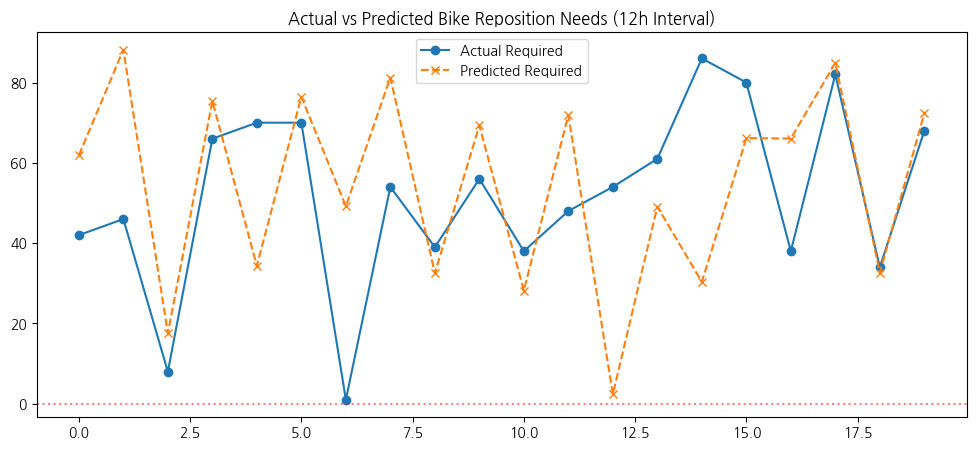

In [130]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

# 1. 시뮬레이션 함수: 임계값 기반 재배치 (가장 현실적인 로직)
# def simulate_smart_reposition(df, capacity=6, min_limit=1, refill_to=3):
#     df = df.sort_values(['기준_날짜', '시간대']).copy()
#     current_stock = refill_to 
#     stocks = []
#     reposition_events = [] # 재배치 수량 기록

#     for _, row in df.iterrows():
#         # 자연 유출입 반영
#         current_stock += row['유출입']
#         current_stock = max(0, min(capacity, current_stock))
        
#         event_val = 0
#         # 오전 4시, 오후 4시에 자전거가 부족(min_limit 이하)하면 보충
#         if row['시간대'] in [4, 16] and current_stock <= min_limit:
#             event_val = refill_to - current_stock
#             current_stock = refill_to
            
#         stocks.append(current_stock)
#         reposition_events.append(event_val)
            
#     df['현재_잔고'] = stocks
#     df['재배치_수량'] = reposition_events
#     return df
# 1. 시프트 구분 (오전 4시~오후 4시 / 오후 4시~익일 오전 4시)
def assign_shift(hour):
    if 4 <= hour < 16:
        return 'Day_to_Evening' # 오후 4시 재배치를 위한 구간
    else:
        return 'Evening_to_Day' # 오전 4시 재배치를 위한 구간

df_1035_station['shift'] = df_1035_station['시간대'].apply(assign_shift)

# 2. 날짜별/시프트별로 데이터를 묶음 (1시간 -> 12시간 단위로 압축)
df_shift = df_1035_station.groupby(['기준_날짜', 'shift']).agg({
    '유출입': 'sum',           # 타겟: 12시간 동안의 총 순유출입
    '온도': 'mean',            # 기상 요인 (평균)
    '습도': 'mean',
    '불쾌지수': 'mean',
    '강수량': 'sum',           # 강수량 (합계)
    'day_type': 'first',
    'month': 'first',
    'weekday': 'first',
    'year': 'first'
}).reset_index()

# 타겟 명확화: 이 값이 양수면 그만큼 채워줘야 하고, 음수면 수거해야 함
df_shift.rename(columns={'유출입': 'required_amount'}, inplace=True)

# 2. 피처 엔지니어링
def engineering_features(df):
    # 시간 관련 주기성 변수
    df['hour_sin'] = np.sin(2 * np.pi * df['시간대'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['시간대'] / 24)
    
    # 재배치 시점까지 남은 시간 (4시, 16시 기준)
    df['time_to_refill'] = df['시간대'].apply(lambda x: (16-x)%12 if x!=4 and x!=16 else 0)
    
    # 과거 데이터 (Lag) - 현재_잔고가 아닌 '유출입' 흐름을 학습
    df['lag_1h'] = df['유출입'].shift(1)
    df['lag_2h'] = df['유출입'].shift(2)
    df['rolling_flow_3h'] = df['유출입'].shift(1).rolling(3).mean()
    
    return df.dropna()

# --- 실행 파트 ---

# [데이터 준비] df_1035_station 사용 (기존에 묶어둔 시간대별 데이터)
# 시뮬레이션 적용 (용량 20, 3대 이하일 때 10대로 충전)
# 'shift'는 문자열이므로 모델 학습을 위해 숫자로 변환 (One-hot Encoding)
df_final = pd.get_dummies(df_shift, columns=['shift'])
df_final = df_final.sort_values(['기준_날짜', 'shift_Day_to_Evening'])
df_final['lag_amount'] = df_final['required_amount'].shift(2) # 어제 같은 시프트의 실제값
df_final = df_final.dropna()

# 피처 리스트 (새로 정의된 컬럼명 반영)
features = [
    '온도', '습도', '불쾌지수', '강수량', 'day_type', 'month', 'weekday',
    'shift_Day_to_Evening', 'shift_Evening_to_Day','lag_amount'
]
target = 'required_amount'

# 2024년 학습 / 2025년 테스트 분리
train = df_final[df_final['year'] == 2024]
test = df_final[df_final['year'] == 2025]

X_train, y_train = train[features], train[target]
X_test, y_test = test[features], test[target]

# [모델 학습]
hgb = HistGradientBoostingRegressor(
    random_state=42,
    max_iter=200,          # 너무 많이 반복하지 않도록 조절
    learning_rate=0.05,    # 학습 속도를 조금 낮춤
    max_leaf_nodes=15      # 모델을 조금 더 단순하게 만듦
)
hgb.fit(X_train, y_train)

# 예측
pred = hgb.predict(X_test)

# 평가 결과 출력
print(f"R2 Score: {r2_score(y_test, pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, pred):.4f}")

# [시각화] 실제 필요량 vs 예측 필요량 비교 (최근 20개 구간만)
plt.figure(figsize=(12, 5))
plt.plot(y_test.values[-20:], label='Actual Required', marker='o')
plt.plot(pred[-20:], label='Predicted Required', marker='x', linestyle='--')
plt.axhline(y=0, color='r', linestyle=':', alpha=0.5)
plt.title('Actual vs Predicted Bike Reposition Needs (12h Interval)')
plt.legend()
plt.show()

In [131]:
# 실제값과 예측값의 차이를 계산
test_results = X_test.copy()
test_results['actual'] = y_test.values
test_results['pred'] = pred
test_results['error'] = abs(test_results['actual'] - test_results['pred'])

# 오차가 가장 큰 Top 5 확인
print(test_results.sort_values(by='error', ascending=False).head(5))

             온도         습도       불쾌지수   강수량  day_type  month  weekday  \
992   14.966667  73.583333  58.488303   0.0         1      5        6   
959   13.816667  74.833333  57.043763   1.9         0      5        4   
898   11.341667  66.833333  52.906938   0.2         0      4        1   
1186  24.033333  96.333333  74.897293  26.6         0      9        0   
1006  20.741667  61.500000  66.317507   0.0         1      6        6   

      shift_Day_to_Evening  shift_Evening_to_Day  lag_amount  actual  \
992                  False                  True        92.0   209.0   
959                   True                 False       136.0     6.0   
898                  False                  True       105.0   161.0   
1186                 False                  True        59.0   132.0   
1006                 False                  True       161.0   156.0   

            pred       error  
992    70.137105  138.862895  
959   107.749272  101.749272  
898    60.981682  100.018318  
1186

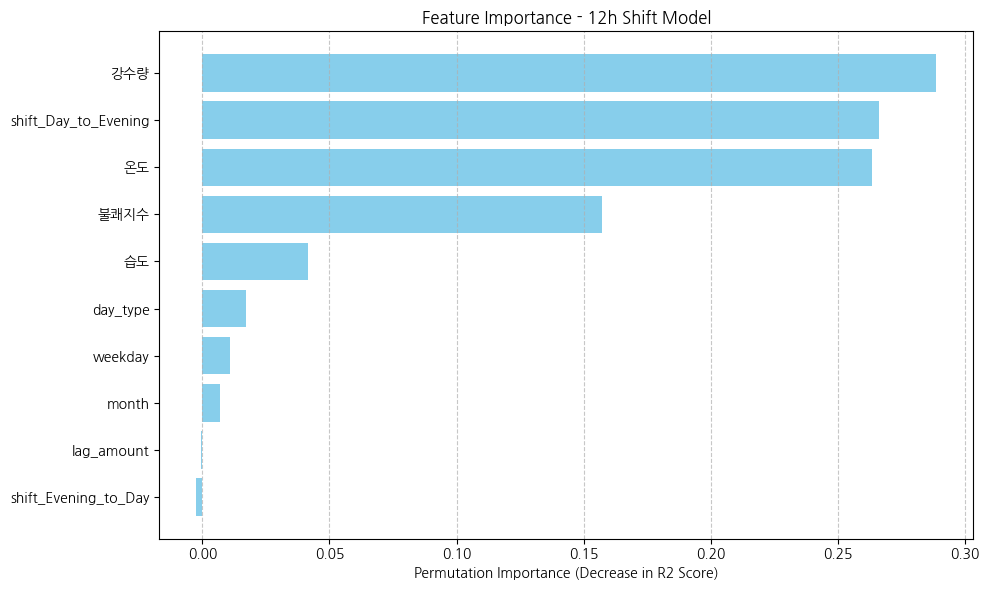

                feature  importance
9                   강수량    0.288724
8  shift_Day_to_Evening    0.266317
7                    온도    0.263498
6                  불쾌지수    0.157307
5                    습도    0.041630
4              day_type    0.017173
3               weekday    0.010975
2                 month    0.007058
1            lag_amount   -0.000459
0  shift_Evening_to_Day   -0.002434


In [132]:
from sklearn.inspection import permutation_importance

# 1. Permutation Importance 계산
result = permutation_importance(
    hgb, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1
)

# 2. 데이터를 보기 좋게 정리
sorted_idx = result.importances_mean.argsort()
importances_df = pd.DataFrame({
    'feature': np.array(features)[sorted_idx],
    'importance': result.importances_mean[sorted_idx]
})

# 3. 시각화
plt.figure(figsize=(10, 6))
plt.barh(importances_df['feature'], importances_df['importance'], color='skyblue')
plt.xlabel("Permutation Importance (Decrease in R2 Score)")
plt.title("Feature Importance - 12h Shift Model")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 4. 수치로 확인
print(importances_df.sort_values(by='importance', ascending=False))